# Feature-importance report — end to end, one schema in, one folder out

**Set the parameters, Run All, get a folder.** This is the operational notebook of
the package: it reads a `unified_schema_*`, joins the pools, ranks every feature,
optionally computes the bar and the holdout, and writes a **self-describing report
directory** — tables as CSV, figures as PNG, a `metadata.json` recording everything
needed to reproduce the run and to know what it may be compared against, and
`outstanding.csv`, the shortlist the rest of the chain reads.

⚠️ **This notebook and `python -m feature_selection.run` produce the SAME artefact**
(aligned 2026-08-16). It did not until then: the CLI recorded `input.columns_by_table`
and an `execution` block and wrote the shortlist, and this notebook did none of the
three — so a run done here was invisible to `final_features`, and one done there was
not. §4a is the file that closes that gap; §0 is the banner that says what it ran on.

The three study notebooks answer *what did we learn*. This one answers *run it and
give me the artefacts*.

| notebook | for |
|---|---|
| [study_1__vcb_unwindowed.ipynb](study_1__vcb_unwindowed.ipynb) | the un-windowed baseline, `d=1` |
| [study_2__vcb_windowed.ipynb](study_2__vcb_windowed.ipynb) | the sequence-model setup, `d=20` |
| [study_3__null_and_holdout.ipynb](study_3__null_and_holdout.ipynb) | whether either result is real (it is not — CONTEXT §6b-6d) |
| [study_4__cross_sectional.ipynb](study_4__cross_sectional.ipynb) | the cross-section, which is (CONTEXT §9) |
| **this one** | **produce and archive a run** |

## ⚠️ Read before quoting anything this writes

**A ranking without a null is descriptive, not evidence.** `RUN_NULL = False` makes
this notebook finish in a minute and produces a `metadata.json` whose `null` field
is `null` and a `README.md` that says so in bold. That is deliberate: CONTEXT §6b
found a positive out-of-sample IC on **shuffled labels**, so `IC > 0` is not a
result. Set `RUN_NULL = True` before the numbers leave your machine.

**A bar belongs to one configuration.** `zscore` moved its own bar 43 % without
touching the data (§6c). Changing the target, the representation, the lookback or
the universe invalidates the previous null — which is why `compare_reports()` puts
those columns beside the IC, so incomparability is visible before the number is.

## Imports

In [1]:
import os
import sys

# ⚠️ EITHER WORKING DIRECTORY MUST WORK - the repo root or this notebook's own
# folder. `sys.path.insert(0, os.path.abspath(".."))` assumed the second: launched
# from the repo root, ".." is the PARENT of the repo and every import below fails
# with ModuleNotFoundError. Walk UP from the CWD to the folder that actually holds
# src/feature_selection, and put that repo's `src` on the path.
#
# REPO_ROOT is reused by the parameter cell: a relative REPORT_ROOT is anchored to
# the repo by `report.write_report` (CONTEXT section 10), so the run folder lands in
# <repo>/reports/feature_selection/ from either CWD - which is the whole point.
def _find_repo_root() -> str:
    here = os.path.abspath(os.getcwd())
    while True:
        if os.path.isdir(os.path.join(here, "src", "feature_selection")):
            return here
        parent = os.path.dirname(here)
        if parent == here:
            raise RuntimeError(
                f"no repo root above {os.getcwd()!r} - expected a folder holding "
                f"src/feature_selection. Start the kernel inside the master-thesis repo."
            )
        here = parent


REPO_ROOT = _find_repo_root()
if os.path.join(REPO_ROOT, "src") not in sys.path:
    sys.path.insert(0, os.path.join(REPO_ROOT, "src"))
print("repo root:", REPO_ROOT)

import pandas as pd
from IPython.display import Image, Markdown, display

# ⚠️ `contract` and `outstanding` are the HANDOFF to `final_features`, and this
# notebook did not import either until 2026-08-16 — it wrote a report folder and
# stopped, one file short of anything downstream being able to see the run
# (`contract.py` §2). `runtime` is the banner every `python -m <stage>` prints.
from feature_selection import contract, evaluation, outstanding, plots, report, windows
from feature_selection.selector import FeatureSelector
from feature_selection.unified_reader import UnifiedSchemaReader
from utils import runtime

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)
plots.use_theme()

repo root: d:\GIT\master-thesis


## Parameters — the whole run is configured here

Everything below this cell is mechanical. ⚠️ Each knob that changes an ANSWER is
recorded into `metadata.json`, so a report is never a bare table of feature names.

In [2]:
TICKER = "VCB"  # the schema is unified_schema_<ticker>

# ── THE THREE KNOBS YOU CHANGE ───────────────────────────────────────────────
# `pool__targets` carries the label and is always joined. Swap `pool__basic` for
# a `pool__economy_<country>` to run a macro pool, or list both to run them
# together. The guard cell below checks they share one calendar before the join.
POOLS = ["pool__basic", "pool__targets"]
TARGET = "close_adjust_5day"
HORIZON = 5  # h — ⚠️ MUST match the target's own horizon (the `5` in its name)
# ─────────────────────────────────────────────────────────────────────────────
#
# ⚠️ **POOL WIDTH IS THE COST, AND IT IS NOT A SMALL FACTOR.** Measured on this
# machine (RTX 3050, DEVICE="cuda", RUN_NULL=False), 2026-08-12:
#
#     pool__basic              15 channels      390 s
#     pool__economy_vietnam    56 channels      540 s
#     pool__economy_japan     171 channels      985 s
#     pool__economy_usa     1,327 channels    expect 1.5-3 h
#
# ⚠️ **THOSE FOUR ARE SIX-RANKER NUMBERS AND BOTH TERMS HAVE MOVED SINCE.**
# (a) `lasso` left the default ensemble on 2026-08-16 (CONTEXT §19), and it was
#     **83.7 % of the 19 archived country runs' wall clock** — measured from their
#     own `timings_seconds`: 6.09 h total, 5.10 h of it lasso. The same sweep on
#     the measured three is ~0.86 h. These figures now OVER-predict by roughly 6x.
# (b) `pool__basic` is no longer 15 channels. The 2026-08-16 rebuild added 58
#     trailing `drv_*` channels, so VCB is **4,266 x 96 = 93 channels**.
# Neither correction is a measurement of THIS run: nothing has been timed on a
# 93-channel `pool__basic` with three rankers. Expect minutes rather than the
# 390 s above or the hours below — and write down what it actually takes.
#
# The three measured points fit ~340 + 3.8n seconds, but that extrapolation is
# OPTIMISTIC for `usa`: the correlation prune and the channel-correlation matrix
# are quadratic in the design width, which at 1,327 channels x 6 window statistics
# is 7,962 columns. Turning RUN_NULL on multiplies whichever figure you get by
# N_NULL, so a 2 h run becomes ~40 h at 20 draws.
#
# TARGET may be any column of pool__targets:
#   return_5day / return_10day              forward simple return
#   return_rel_5day / return_rel_10day      the same, minus the VNINDEX return
#   close_adjust_5day / close_adjust_10day  the forward adjusted CLOSE (a level)
#
# ⚠️ A level target is not a forecasting problem in the way a return is. Measured
# 2026-08-12: `close_adjust` alone ranks `close_adjust_5day` at rho = 0.996 and
# takes rank 1 on all six rankers, because a price and the same price five
# sessions later are the same trend. Read the SCALE, not the order.

# EVERY non-key column of pool__targets, THE TARGET INCLUDED. Whichever is not
# the target is excluded from the candidate features by `EXCLUDE` below.
#
# ⚠️ **THIS WAS `OTHER_TARGETS` AND IT WAS CORRECT FOR EXACTLY ONE TARGET.** It
# listed the five labels *other than* `return_5day`, which works only while
# TARGET is `return_5day`. Change TARGET to `close_adjust_5day` and `return_5day`
# is no longer on the list, is not excluded, and becomes a candidate FEATURE — a
# forward return predicting a forward price. That does not raise; it reports a
# near-perfect IC and looks like a discovery. Listing them ALL and subtracting the
# target is correct for every choice, which is why the name changed with the list.
#
# ⚠️ Keep in step with `feature_selection.run.ALL_TARGETS`. The guard cell checks
# this against information_schema and stops the run if the table has since grown.
# ⚠️ **AND IT DRIFTED ANYWAY — THIS WAS THE THIRD HAND-MAINTAINED COPY.** The
# three h=20 labels landed in `run.ALL_TARGETS` with the 4-week horizon (commit
# `e87a3fa7`) and not here, so on 2026-08-18 the guard cell below raised on a
# Kaggle worker and killed the run: `pool__targets holds label column(s)
# ['return_20day', 'return_rel_20day', 'close_adjust_20day'] that ALL_TARGETS does
# not name`. That is the guard working exactly as designed — and one list would
# have made it unnecessary. Imported now, from the module that owns it.
from feature_selection.run import ALL_TARGETS

LOOKBACK = 20  # d — window length in sessions; 1 = un-windowed
NORMALIZE = "none"  # "none" | "zscore" | "window_relative"
MAX_FEATURES = None  # None = the per-run MEASURED cut (selection_cut, STL-1).
# A number here re-imposes a flat cap, which is almost never what you want: 12
# was chosen for a 27-channel pool and then applied to a 1,458-channel one.
CORR_THRESHOLD = 0.9
N_SPLITS, MIN_TRAIN = 5, 500
DEVICE = "cuda"  # ⚠️ part of the setup, NOT a speed knob — see gpu.py §1.
# "cuda" = every ranker on the GPU. "auto" keeps narrow pools on the host.
RANDOM_STATE = 18  # the SELECTOR seed; the null draws from NULL_SEED=7

RUN_STABILITY = True  # per-fold SHAP ranking (cheap)
RUN_NULL = True  # ⚠️ the BAR. Slow. See the warning above.
N_NULL = 10
RUN_HOLDOUT = False  # score an untouched tail once, with a control
HOLDOUT_START = "2024-06-01"

TOP_N_FIGURES = 30

# ⚠️ THE REPORT ROOT IS A GROUP, NOT A FOLDER PREFERENCE.
# `final_features` unions EVERY run under one root by (schema, target, setup) —
# a key with no term for which pools. ONE root holds every run since 2026-08-10.
#
# ⚠️ **WHAT THIS RUN WILL DO, AND IT IS NOT WHAT IT USED TO DO — MTH-1, fixed
# 2026-08-16.** `methods` is in `contract.SETUP_KEYS` now, so this run (three
# rankers) is NOT the same setup as the 19 archived country runs, which recorded
# no ensemble and read as `"unrecorded"`. They are two groups. But both still want
# the name `close_adjust_5day__final__d20_h5`, so `final_features` will **RAISE on
# the collision instead of unioning them** — the guard working, not a failure:
#
#     python -m final_features --scope basic     # -> ..._d20_h5__basic
#
# Before the fix those two were ONE group and were silently unioned. Separate a
# build with `--scope`, never with a second root.
#
# ⚠️ RELATIVE, AND ANCHORED TO THE REPO - NOT TO THE CWD. `write_report` joins a
# relative root onto REPO_ROOT, so this lands in <repo>/reports/feature_selection/
# whether the kernel starts at the repo root or in this folder. It did NOT until
# 2026-08-10: a complete run went to src/feature_selection/reports/feature_selection/,
# where outstanding, final_features and pipeline all correctly saw no run at all.
REPORT_ROOT = "reports/feature_selection"
NOTES = ""  # free text, lands in metadata.json and README.md

# ⚠️ Identity and taxonomy columns are never candidates. On a single-ticker panel
# they are constant and would be dropped anyway; naming them keeps that a decision
# rather than an accident, and keeps this cell correct for a multi-ticker panel.
from feature_selection.run import IDENTITY  # one list, for the same reason

# ⚠️ Built ONCE, here, and passed to both the selector and the null's factory.
# They were two separate literal expressions, which is two places for the same
# rule to drift — and a null built on a different exclude list is not a bar for
# the run it judges (CONTEXT §9d).
EXCLUDE = IDENTITY + [c for c in ALL_TARGETS if c != TARGET]

if TARGET not in ALL_TARGETS:
    raise ValueError(
        f"TARGET {TARGET!r} is not in ALL_TARGETS. Add it there too, or it will "
        f"not be excluded from the features of a run that targets something else."
    )
print(f"{TICKER} · {TARGET} · d={LOOKBACK} h={HORIZON}")
print(f"pools: {POOLS}")
print(f"excluding {len(EXCLUDE)} columns — {len(IDENTITY)} identity + "
      f"{len(ALL_TARGETS) - 1} other labels")

VCB · close_adjust_5day · d=20 h=5
pools: ['pool__basic', 'pool__targets']
excluding 15 columns — 10 identity + 5 other labels


## 0. The banner — what ran, on what, and how long it took

⚠️ **`device` is part of the SETUP here, not a speed knob.** The same selection on
`cuda` and on `cpu` keeps a *different* feature set (`gpu.py` §1), so a run that
does not say which one it used cannot be reproduced. And the runtime is the number
the cost model in CONTEXT §15c is fitted on — it was previously visible only in
whatever console the notebook happened to be attached to.

Three different facts, printed as three: the **hardware in the box** (`gpu`), the
device this run **asked for** (below), and the device the selector **resolved** (§2).


In [3]:
# ⚠️ **STARTED BEFORE THE READ, NOT BEFORE THE FIT.** A wide pool spends minutes in
# PostgreSQL and that time is part of what a run costs — `feature_selection.run` times
# the same span, so the two entry points' runtimes go into the same cost model.
#
# ⚠️ `device=DEVICE` is the PREFERENCE. `auto` is not an answer: it sends a narrow pool
# to the host and a wide one to the GPU, and the two do not keep the same channels. The
# RESOLVED device replaces it in §2, once the selector has one — a request is never
# evidence of what happened (CLAUDE.md §5 rule 10, at the hardware).
timer = runtime.RunTimer(
    f"RUN__feature_importance_report  {TICKER} / {'+'.join(POOLS)} -> {TARGET} "
    f"(d={LOOKBACK}, h={HORIZON}, null_draws={N_NULL if RUN_NULL else 0})",
    device=DEVICE,
).start()


RUN__feature_importance_report  VCB / pool__basic+pool__targets -> close_adjust_5day (d=20, h=5, null_draws=10)
started   2026-08-16 12:31:41 GMT+7
device    cuda
gpu       NVIDIA GeForce RTX 3050 Laptop GPU  |  4,096 MiB total, 3,303 MiB free  |  CUDA 12.1, torch 2.5.1+cu121   [torch]


## 1. Read and join

`UnifiedSchemaReader` types every column from `information_schema` rather than
guessing — psycopg2 returns `numeric` as `Decimal`, which pandas stores as dtype
`object`, so `close_adjust` would otherwise arrive looking like a string column.

⚠️ **`join_log` records which keys each merge actually used** and goes into the
report. Every pool is keyed `(date, exchange, ticker)` as of 2026-08-04, but the
join intersects per pair rather than assuming, so a pool that predates the change
joins correctly instead of silently wrongly.

In [4]:
# ⚠️ THE CALENDAR GUARD. `reader.join` is an INNER join, so a `pool__economy_<country>`
# that is older than `pool__basic` does NOT fail - it silently truncates the panel to
# its own last date and every number below describes the shorter window. Nothing in the
# archived run can reveal that afterwards. Measured 2026-08-10: pool__basic had moved to
# 2026-08-07 while all 19 economy pools sat at 2026-06-25 - six weeks, invisibly.
#
# The Dagster asset `analysis/feature_selection_economy` asserts this before it starts.
# The notebook has no such wrapper, so the check lives here.
#
# ⚠️ AND THE LABEL GUARD, added 2026-08-12. `ALL_TARGETS` is maintained by hand, and a
# hand-maintained list drifts the moment the table gains a column - which is exactly
# what happened when `close_adjust_{h}day` was added. A label this notebook does not
# KNOW is a label is handed to FeatureSelector as a candidate CHANNEL: it does not
# raise, it reports an IC near 1. So the list is checked against information_schema
# rather than trusted. `feature_selection.run` does the same check for the CLI path.
_POOLS = list(POOLS) if "pool__targets" in POOLS else list(POOLS) + ["pool__targets"]
with UnifiedSchemaReader(TICKER) as _r:
    _spans = {
        t: _r.read(t)["date"].agg(["min", "max", "count"]).to_dict()
        for t in _POOLS
    }
    _labels = [c for c in _r.column_types("pool__targets")
               if c not in ("date", "exchange", "ticker")]

_unlisted = [c for c in _labels if c not in ALL_TARGETS]
if _unlisted:
    raise ValueError(
        f"pool__targets holds label column(s) {_unlisted} that ALL_TARGETS does not "
        f"name. They would be selected over as FEATURES. Add them to ALL_TARGETS in "
        f"the parameter cell (and to feature_selection.run.ALL_TARGETS)."
    )

_ends = {t: s["max"] for t, s in _spans.items()}
for _t, _s in _spans.items():
    print(f"{_t:<28} {_s['count']:>7,} rows  {_s['min']:%Y-%m-%d} .. {_s['max']:%Y-%m-%d}")
assert len(set(_ends.values())) == 1, (
    f"pools end on different dates {_ends} - the INNER join would truncate to the "
    f"earliest. Re-materialise unified/pool__economy on this universe first."
)
print(f"OK - every pool shares one calendar, and ALL_TARGETS covers all "
      f"{len(_labels)} label column(s).")

pool__basic                    4,266 rows  2009-06-30 .. 2026-08-07
pool__targets                  4,266 rows  2009-06-30 .. 2026-08-07
OK - every pool shares one calendar, and ALL_TARGETS covers all 6 label column(s).


In [5]:
reader = UnifiedSchemaReader(TICKER).connect()
overview = reader.overview()
panel = reader.join(POOLS)
join_log = reader.join_log
# ⚠️ **THE ONLY PLACE THAT KNOWS WHICH POOL EACH CHANNEL CAME FROM**, and this
# notebook threw it away until 2026-08-16. Without it `feature_selection.outstanding`
# falls back to guessing the pool from the channel NAME, which returns `unknown` for
# every pool built since 2026-08-10 — `pool__bonds`, `pool__forex_*`, `pool__funds`,
# `pool__stock_market`, `pool__basic_bank` — and `final_features` cannot build a FROM
# clause for a channel it cannot locate. The silent case is worse: with `pool__ta` in
# the run the guess NAMES `pool__ta` for a forex channel, which is a table that EXISTS
# and does not hold the column, so the error arrives from PostgreSQL two stages later
# (`contract.py` §1).
columns_by_table = dict(reader.columns_by_table)
schema_name, database = reader.schema, reader.database
reader.close()

print(
    f"{schema_name}: {panel.shape[0]:,} rows x {panel.shape[1]} columns "
    f"({panel['date'].min():%Y-%m-%d} -> {panel['date'].max():%Y-%m-%d})"
)
print("channels per pool: " + ", ".join(
    f"{table} {len(channels)}" for table, channels in columns_by_table.items()
))
overview

unified_schema_vcb: 4,266 rows x 102 columns (2009-06-30 -> 2026-08-07)
channels per pool: pool__basic 93, pool__targets 6


,table,rows,columns,key_columns,first_date,last_date
0,close_adjust_5day__final__d20_h5,4266,889,"date, exchange, ticker",2009-06-30,2026-08-07
1,pool__basic,4266,96,"date, exchange, ticker",2009-06-30,2026-08-07
2,pool__basic_bank,4266,543,"date, exchange, ticker",2009-06-30,2026-08-07
3,pool__bonds,4266,120,"date, exchange, ticker",2009-06-30,2026-08-07
4,pool__economy_australia,4266,163,"date, exchange, ticker",2009-06-30,2026-08-07
...,...,...,...,...,...,...
72,pool__funds,4266,392,"date, exchange, ticker",2009-06-30,2026-08-07
73,pool__shortlist__close_adjust_5day__d20_h5,4266,892,"date, exchange, ticker",2009-06-30,2026-08-07
74,pool__stock_market,4266,165,"date, exchange, ticker",2009-06-30,2026-08-07
75,pool__ta,4236,921,"date, exchange, ticker",2009-06-30,2026-06-26


In [6]:
pd.DataFrame(join_log)

,table,join_keys,how,rows_before,rows_after,columns_added,duplicate_columns_dropped
0,pool__targets,"date, exchange, ticker",inner,4266,4266,6,


### The target's own arithmetic

In [7]:
# Every label the schema has, the run's TARGET first. ⚠️ `mean`/`sd` are in each
# label's OWN units — a return is ~0.003, a `close_adjust_*` level is ~27,000 —
# so these rows are not comparable down the column.
labels = pd.DataFrame(
    [
        {
            "target": column,
            "is_target": column == TARGET,
            "labelled": int(panel[column].notna().sum()),
            "unlabelled_tail": int(panel[column].isna().sum()),
            "mean": round(float(panel[column].mean()), 6),
            "sd": round(float(panel[column].std()), 6),
        }
        for column in (
            [TARGET] + [c for c in ALL_TARGETS if c != TARGET and c in panel.columns]
        )
    ]
)
labels

,target,is_target,labelled,unlabelled_tail,mean,sd
0,close_adjust_5day,True,4261,5,27692.290542,20542.148182
1,return_5day,False,4261,5,0.003149,0.043027
2,return_10day,False,4256,10,0.006275,0.059864
3,return_rel_5day,False,4253,13,0.001021,0.031979
4,return_rel_10day,False,4248,18,0.002075,0.043732
5,close_adjust_10day,False,4256,10,27715.291353,20543.236382


## 2. Run the selection

Six rankers → rank-average ensemble → correlation prune at channel level → purged
walk-forward. ⚠️ The purge gap is `d + h - 1`, not `h` (CONTEXT §1a).

In [8]:
selector = FeatureSelector(
    panel=panel,
    target=TARGET,
    exclude=EXCLUDE,          # built once in the parameter cell, shared with the null
    max_features=MAX_FEATURES,
    corr_threshold=CORR_THRESHOLD,
    horizon=HORIZON,
    lookback=LOOKBACK,
    window_stats=windows.WINDOW_STATS,
    normalize=NORMALIZE,
    n_splits=N_SPLITS,
    min_train=MIN_TRAIN,
    device=DEVICE,
    random_state=RANDOM_STATE,
    holdout_start=HOLDOUT_START if RUN_HOLDOUT else None,
)

result = selector.run(stability=RUN_STABILITY)

# ⚠️ The RESOLVED device, not the preference — and they differ on 14 of the 19
# country pools under `auto`. Twenty-two archived selections recorded `device=cpu`
# while everyone believed the GPU was busy (`gpu.py` §4); this is the line that
# would have said so, and it is what `metadata.json` records below.
timer.set_device(selector.device)
print(
    f"device: requested {DEVICE!r} -> resolved {selector.device!r}   "
    f"elapsed {runtime.format_duration(timer.elapsed)}"
)
result.setup.to_frame().T

  [1/9 phases  11%] prepare + coverage          0.0s
  [2/9 phases  22%] window design               0.4s
  [3/9 phases  33%] spearman vs target          0.2s
  [4/9 phases  44%] rank (the ensemble's methods)     11.2s
  [5/9 phases  56%] aggregate + blend           0.0s
  [6/9 phases  67%] channel corr matrix         0.1s
  [7/9 phases  78%] prune                       0.0s
  [8/9 phases  89%] stability                  10.8s


d:\GIT\master-thesis\mt_env\Lib\site-packages\xgboost\core.py:158: UserWarning: [12:32:07] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\common\error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  warnings.warn(smsg, UserWarning)


  [9/9 phases 100%] walk-forward               19.6s
device: requested 'cuda' -> resolved 'cuda'   elapsed 43.8 s


,target,horizon_h,lookback_d,normalize,purge_gap_rows,window_stats,dropped_by_normalize,dev_samples,holdout_start,holdout_rows,purged_at_boundary,channels,design_columns,kept,device,methods
setup,close_adjust_5day,5,20,none,24,"last, mean, slope, sd, min, max",0,4242,—,0,0,84,504,57,cuda,"spearman, xgb_shap, permutation"


### The ranking — this is the deliverable

In [9]:
result.ranking.round(3)

,ensemble,kept,dropped_for,spearman,xgb_shap,permutation
drv_amihud_21,6.000,True,,0.930,0.006,0.163
n_sell_orders,6.333,True,,0.889,0.002,0.312
close_adjust,7.000,False,drv_amihud_21,1.000,1.000,0.103
drv_amihud_63,10.667,False,drv_amihud_21,0.936,0.003,0.094
avg_vol_per_sell_order,15.000,True,,0.559,0.002,0.188
...,...,...,...,...,...,...
drv_rogers_satchell_21,65.667,False,drv_parkinson_21,0.071,0.000,0.029
drv_garman_klass_21,67.667,False,drv_parkinson_21,0.096,0.000,0.036
drv_intraday_pct,70.000,False,drv_body_pct,0.234,0.000,0.010
drv_prop_net_value_ratio,72.667,True,,0.230,0.000,0.000


In [10]:
print("kept:", result.kept)
print("\ndropped as redundant:")
display(pd.Series(result.dropped_correlated, name="duplicated").to_frame())
if result.dead_methods:
    print(f"\n⚠️ dead methods (separated nothing): {result.dead_methods}")

kept: ['drv_amihud_21', 'n_sell_orders', 'avg_vol_per_sell_order', 'drv_order_fill_ratio', 'drv_vwap_raw', 'drv_order_vol_imb_21', 'avg_vol_per_buy_order', 'drv_realized_vol_63', 'drv_dist_from_high_252', 'drv_order_vol_imb', 'drv_negotiated_value_share', 'drv_dist_from_high_63', 'drv_order_vol_imb_5', 'drv_clv', 'drv_foreign_flow_ratio_21', 'drv_foreign_net_value_ratio', 'foreign_room_left', 'drv_foreign_own_chg_21', 'foreign_own', 'drv_close_z_63', 'drv_gap_open_pct', 'drv_ret_skew_63', 'prop_sell_val', 'drv_order_count_imb_5', 'foreign_buy_volume', 'drv_ret_kurt_63', 'drv_lower_shadow', 'drv_upper_shadow', 'prop_buy_vol', 'drv_order_count_imb', 'sell_order_vol', 'foreign_sell_value', 'drv_close_pos_21', 'drv_volume_z_21', 'drv_dist_from_high_21', 'drv_parkinson_21', 'foreign_net_value', 'drv_order_count_imb_z21', 'drv_vol_ratio_10_63', 'drv_parkinson_5', 'drv_log_order_size_ratio', 'drv_order_count_imb_21', 'drv_body_pct', 'drv_realized_vol_10', 'drv_close_vs_vwap', 'drv_foreign_par

,duplicated
close_adjust,drv_amihud_21
drv_amihud_63,drv_amihud_21
value_matched,n_sell_orders
high,drv_vwap_raw
drv_close_pos_252,drv_dist_from_high_252
open,drv_vwap_raw
close_raw,drv_vwap_raw
low,drv_vwap_raw
n_buy_orders,n_sell_orders
value_negotiated,drv_negotiated_value_share


### Walk-forward — the only numbers carrying a generalisation claim

In [11]:
display(result.validation.round(4))
evaluation.ic_summary(result.validation, HORIZON).to_frame().T.round(4)

,fold,feature_set,n_channels,n_columns,n_train,n_test,n_eff_test,ic,r2,hit_rate
0,fold 1,all channels,84,504,500,743,148.6,0.8332,0.3570,1.0
1,fold 1,selected,57,342,500,743,148.6,0.5381,-0.1150,1.0
2,fold 2,all channels,84,504,1243,743,148.6,-0.0672,-5.3068,1.0
3,fold 2,selected,57,342,1243,743,148.6,0.2597,-6.4011,1.0
4,fold 3,all channels,84,504,1986,743,148.6,-0.1586,-4.4440,1.0
5,fold 3,selected,57,342,1986,743,148.6,-0.2300,-6.9259,1.0
6,fold 4,all channels,84,504,2729,743,148.6,0.3324,-3.0984,1.0
7,fold 4,selected,57,342,2729,743,148.6,0.4274,-3.0545,1.0
8,fold 5,all channels,84,504,3472,746,149.2,0.0358,-15.4299,1.0
9,fold 5,selected,57,342,3472,746,149.2,0.1521,-55.4588,1.0


,folds,ic_mean,ic_trend_per_fold,ic_min,ic_max,ic_fold_sd,hit_rate,n_test_rows,n_eff_per_fold,se_ic_per_fold
selected,5.0,0.2295,-0.0604,-0.23,0.5381,0.2968,1.0,743.0,148.6,0.0823


## 3. The bar, and the holdout

⚠️ Both are optional and both are OFF by default, because both are slow — and both
are what turn a ranking into evidence. A report written without them says so.

In [12]:
null = None
if RUN_NULL:

    def factory(frame):
        # ⚠️ Same EXCLUDE object as the run above. The null must be the SAME
        # procedure as the thing it judges (CONTEXT §9d) — a bar computed with a
        # different candidate set is not a bar for this run.
        clone = FeatureSelector(
            panel=frame,
            target=TARGET,
            exclude=EXCLUDE,
            max_features=MAX_FEATURES,
            corr_threshold=CORR_THRESHOLD,
            horizon=HORIZON,
            lookback=LOOKBACK,
            normalize=NORMALIZE,
            n_splits=N_SPLITS,
            min_train=MIN_TRAIN,
            device=DEVICE,
            random_state=RANDOM_STATE,
        )
        return clone.run(stability=False)

    observed = evaluation.ic_summary(result.validation, HORIZON)["ic_mean"]
    null = evaluation.null_distribution(
        panel=panel,
        target=TARGET,
        factory=factory,
        observed=observed,
        horizon=HORIZON,
        lookback=LOOKBACK,
        n_draws=N_NULL,
        seed=7,
        label=f"{schema_name} / {TARGET}",
    )
    display(null.summary().to_frame().T)
else:
    print("⚠️ RUN_NULL is False — this report will record that no bar was computed.")
    print("   N_NULL=20 re-runs the whole selection 20 times; on pool__basic that "
          "is minutes, on a 171-channel macro pool it is hours.")

  draw   1/10  10%  null mean IC -0.0281   [0.5 min elapsed, ~4.6 min left]
  draw   2/10  20%  null mean IC +0.0543   [1.0 min elapsed, ~4.0 min left]
  draw   3/10  30%  null mean IC +0.0795   [1.5 min elapsed, ~3.5 min left]
  draw   4/10  40%  null mean IC +0.0871   [2.0 min elapsed, ~3.0 min left]
  draw   5/10  50%  null mean IC +0.0015   [2.5 min elapsed, ~2.5 min left]
  draw   6/10  60%  null mean IC -0.0350   [3.0 min elapsed, ~2.0 min left]
  draw   7/10  70%  null mean IC +0.0612   [3.5 min elapsed, ~1.5 min left]
  draw   8/10  80%  null mean IC -0.0273   [4.0 min elapsed, ~1.0 min left]
  draw   9/10  90%  null mean IC +0.0150   [4.5 min elapsed, ~0.5 min left]
  draw  10/10 100%  null mean IC -0.0018   [5.0 min elapsed, ~0.0 min left]


,label,observed_ic,null_mean,null_sd,null_p95_BAR,null_max,p_value,z_vs_null,clears_bar,draws,failed_draws
unified_schema_vcb / close_adjust_5day,unified_schema_vcb / close_adjust_5day,0.2295,0.0207,0.0464,0.0837,0.0871,0.0909,4.5,True,10,0


In [13]:
holdout = selector.score_holdout(result) if RUN_HOLDOUT else None
if holdout is not None:
    display(holdout.round(4))

## 4. Write the report — and the shortlist `final_features` reads

One folder: `metadata.json`, `README.md`, the CSVs, `figures/*.png` — **and
`outstanding.csv`**.

⚠️ **Two arguments here are the whole handoff, and both were missing until
2026-08-16.** `columns_by_table` is which pool each channel came from, without which
the next stage guesses from the channel name and hands `final_features` `unknown`;
`execution` is when this ran, on what hardware, and for how long. `metadata.json`
carries both, `outstanding.csv` carries the first into the fetch list, and
`final_features` copies the provenance from there into the table's own `COMMENT`.


In [14]:
written = report.write_report(
    result,
    selector=selector,
    panel=panel,
    schema=schema_name,
    tables=POOLS,
    database=database,
    join_log=join_log,
    null=null,
    holdout=holdout,
    notes=NOTES,
    top=TOP_N_FIGURES,
    root=REPORT_ROOT,
    # ⚠️ The two facts a run folder could not previously state about itself: which
    # pool each channel came from, and what the run cost on what hardware.
    columns_by_table=columns_by_table,
    # ⚠️ `summary()` reads a LIVE elapsed time on purpose — THIS call is what writes
    # the file the block goes into, so waiting for the finish banner would record a
    # zero. The banner itself is the cell after the shortlist.
    execution=timer.summary(),
)
written.summary().to_frame().T

,run_id,schema,tables,target,rows,channels,kept,ic_mean,ic_trend,hit_rate,null_bar,clears_null,files,path
report,2026-08-16_123727__vcb__basic__close_adjust_5day,unified_schema_vcb,"pool__basic, pool__targets",close_adjust_5day,4266,84,57,0.229457,-0.060414,1.0,0.0837,True,20,d:\GIT\master-thesis\reports\feature_selection...


In [15]:
print(written.path)
for artefact in written.metadata["artifacts"]:
    print(f"  {artefact['bytes']:>9,}  {artefact['file']}")

d:\GIT\master-thesis\reports\feature_selection\2026-08-16_123727__vcb__basic__close_adjust_5day
     12,007  feature_importance.csv
     39,178  design_scores.csv
        919  validation.csv
      3,282  target_correlation.csv
    144,249  channel_correlation.csv
      3,680  stability.csv
      3,009  coverage.csv
        253  null_draws.csv
    146,667  figures/01_ensemble_ranking.png
    202,868  figures/02_method_heatmap.png
    135,214  figures/03_target_correlation.png
    282,057  figures/04_channel_correlation.png
    124,282  figures/05_stat_profile.png
     44,981  figures/06_validation.png
    179,739  figures/07_stability.png
    268,635  figures/08_coverage.png
     45,467  figures/09_target_distribution.png
     53,871  figures/10_null.png


### 4a. `outstanding.csv` — the one file that makes this run visible downstream

⚠️ **A report folder without it is INVISIBLE.** `final_features.plan_from_reports`
skips any folder carrying no shortlist, and says nothing about it — two finished
Kaggle runs sat in exactly that state on 2026-08-15 and `final_features` planned 19
runs and reported no error (`contract.py` §2). `python -m feature_selection.run` has
always written it here; this notebook did not, which made the interactive path and
the scripted path produce two different kinds of artefact from the same code.

`contract.validate_shortlist` then checks the file the *consumer* will read: the
columns it needs, the SQL-identifier rule every one of them is interpolated under,
and above all that no channel carries `source_table='unknown'`.


In [16]:
# ⚠️ **THE ROOT MUST BE THE ONE `write_report` RESOLVED, NEVER `REPORT_ROOT`.**
# `REPORT_ROOT` is relative and `write_report` anchors it to the REPO; `outstanding.main`
# would join it against the CWD, which in Jupyter is this notebook's own folder. Passing
# the string scans `src/feature_selection/reports/feature_selection/`, finds no run and
# reports success having written nothing — the same CWD trap that sent 22 runs into the
# wrong tree in 2026-08-10 (`report.write_report`).
RUN_ROOT = os.path.dirname(written.path)

# `strict=False`: report every problem, write nothing bad, and let this cell decide about
# THIS run. A sibling run's broken shortlist is a real finding and it must not raise in
# the middle of reporting on a run that just finished (CLAUDE.md §5 rule 20).
shortlists = outstanding.main(root=RUN_ROOT, strict=False)
mine = shortlists.get(os.path.basename(written.path))

if mine is None:
    raise RuntimeError(
        f"no {contract.SHORTLIST_FILENAME} was written for {os.path.basename(written.path)} "
        f"— the WARNING lines above say why. `final_features` cannot see this run until "
        f"it exists; the report folder itself is already on disk and is not lost."
    )

print(
    f"shortlist: {len(mine)} channels, evidence={mine['evidence'].iloc[0]}, "
    f"source_table from {mine['source_table_from'].iloc[0]}, "
    f"pools {sorted(set(mine['source_table']))}"
)

# The run is over here — everything below this cell reads back what it wrote.
timer.stop()
mine


shortlist: 20 channels, evidence=cleared_p95_not_a_pass, source_table from metadata, pools ['pool__basic']

finished  2026-08-16 12:37:34 GMT+7   runtime 5m 53s (352.9 s)   device cuda


,outstanding_rank,channel,schema,source_table,grain,ensemble,permutation,spearman_vs_target,best_stat,kept_by,consensus_p,tie_group_size,beat_in_tie,absorbed_as_redundant,n_candidates,run_id,target,horizon_h,lookback_d,evidence,source_table_from,coverage,coverage_flag,cut_fdr_q,cut_corr_threshold
0,1,drv_amihud_21,unified_schema_vcb,pool__basic,date,6.000000,0.162625,-0.927053,sd,consensus+specialist,0.001490,1,,close_adjust; drv_amihud_63,34,2026-08-16_123727__vcb__basic__close_adjust_5day,close_adjust_5day,5,20,cleared_p95_not_a_pass,metadata,0.995306,,0.1,0.9
1,2,n_sell_orders,unified_schema_vcb,pool__basic,date,6.333333,0.312084,0.818965,mean,consensus+specialist,0.001780,1,,n_buy_orders; value_matched,34,2026-08-16_123727__vcb__basic__close_adjust_5day,close_adjust_5day,5,20,cleared_p95_not_a_pass,metadata,0.963858,,0.1,0.9
2,3,avg_vol_per_sell_order,unified_schema_vcb,pool__basic,date,15.000000,0.188052,-0.497217,min,specialist,0.023999,1,,,34,2026-08-16_123727__vcb__basic__close_adjust_5day,close_adjust_5day,5,20,cleared_p95_not_a_pass,metadata,0.963858,,0.1,0.9
3,4,drv_order_fill_ratio,unified_schema_vcb,pool__basic,date,17.666667,1.000000,0.183074,sd,specialist,0.039517,1,,,34,2026-08-16_123727__vcb__basic__close_adjust_5day,close_adjust_5day,5,20,cleared_p95_not_a_pass,metadata,0.954236,,0.1,0.9
4,5,drv_vwap_raw,unified_schema_vcb,pool__basic,date,19.666667,0.042241,0.862271,min,specialist,0.054958,1,,close_raw; high; low; open,34,2026-08-16_123727__vcb__basic__close_adjust_5day,close_adjust_5day,5,20,cleared_p95_not_a_pass,metadata,1.000000,,0.1,0.9
5,6,drv_order_vol_imb_21,unified_schema_vcb,pool__basic,date,21.333333,0.472929,0.321909,mean,specialist,0.070428,1,,,34,2026-08-16_123727__vcb__basic__close_adjust_5day,close_adjust_5day,5,20,cleared_p95_not_a_pass,metadata,0.969021,,0.1,0.9
6,7,avg_vol_per_buy_order,unified_schema_vcb,pool__basic,date,25.000000,0.040079,-0.555784,sd,specialist,0.113896,1,,drv_avg_order_size,34,2026-08-16_123727__vcb__basic__close_adjust_5day,close_adjust_5day,5,20,cleared_p95_not_a_pass,metadata,0.963858,,0.1,0.9
7,8,drv_order_vol_imb,unified_schema_vcb,pool__basic,date,27.333333,0.053091,0.150707,slope,specialist,0.149441,1,,,34,2026-08-16_123727__vcb__basic__close_adjust_5day,close_adjust_5day,5,20,cleared_p95_not_a_pass,metadata,0.954236,,0.1,0.9
8,9,drv_dist_from_high_63,unified_schema_vcb,pool__basic,date,31.666667,0.310262,0.264188,last,specialist,0.232594,1,,,34,2026-08-16_123727__vcb__basic__close_adjust_5day,close_adjust_5day,5,20,cleared_p95_not_a_pass,metadata,0.985449,,0.1,0.9
9,10,value_negotiated,unified_schema_vcb,pool__basic,date,36.000000,0.043307,0.499907,mean,specialist,0.333840,1,,volume_negotiated,34,2026-08-16_123727__vcb__basic__close_adjust_5day,close_adjust_5day,5,20,cleared_p95_not_a_pass,metadata,1.000000,,0.1,0.9


### 4b. The handoff, as `final_features` will see it

⚠️ **Read-only.** One row per run folder under this root and whether it satisfies the
contract — what the next `python -m final_features` will find, without running it.

⚠️ **A run here is not a run in isolation.** `final_features` groups EVERY run under
one root by `(schema, target, setup)` — a key with **no term for which pools** — so a
`pool__basic` run and a country run at the same seed are unioned into ONE table.
Separate a build with `--scope`, never with a second root.


In [17]:
contract.describe(RUN_ROOT)


,run,channels,ok,problem
0,2026-08-12_130605__vcb__economy_vietnam__close...,28,True,
1,2026-08-12_205927__vcb__economy_japan__close_a...,85,True,
2,2026-08-13_001037__vcb__economy_usa__close_adj...,87,True,
3,2026-08-13_010024__vcb__economy_australia__clo...,46,True,
4,2026-08-13_012144__vcb__economy_european_union...,53,True,
5,2026-08-13_014705__vcb__economy_germany__close...,64,True,
6,2026-08-13_020732__vcb__economy_hong_kong_chin...,50,True,
7,2026-08-13_022416__vcb__economy_india__close_a...,41,True,
8,2026-08-13_023427__vcb__economy_indonesia__clo...,46,True,
9,2026-08-13_024708__vcb__economy_mainland_china...,32,True,


### The README the run wrote about itself

In [18]:
display(
    Markdown(open(os.path.join(written.path, "README.md"), encoding="utf-8").read())
)

# Feature-importance run — `close_adjust_5day`

*Generated 2026-08-16T12:37:30+07:00 at commit `f912ee40+dirty`.*

## Input

- **schema** `unified_schema_vcb` (database `database_main_v2`)
- **tables** `pool__basic`, `pool__targets`
- **panel** 4,266 rows x 102 columns
- **range** 2009-06-30 to 2026-08-07 (4266 sessions, 1 tickers)

## Target

- **`close_adjust_5day`** — close_adjust_5day (see cross_sectional.py / DataPreprocessor for the definition)
- horizon **5** sessions; 4,261 labelled, 5 unlabelled
- mean +27692.29054, sd 20542.14818, range +4400.0000 to +76000.0000

## Setup

| knob | value |
|---|---|
| `selector_class` | FeatureSelector |
| `lookback_d` | 20 |
| `horizon_h` | 5 |
| `normalize` | none |
| `purge_gap_rows` | 24 |
| `window_stats` | last, mean, slope, sd, min, max |
| `n_splits` | 5 |
| `min_train` | 500 |
| `corr_threshold` | 0.9 |
| `device` | cuda |
| `random_state` | 18 |
| `permutation_repeats` | 10 |
| `holdout_start` | — |
| `dev_samples` | 4242 |
| `design_columns` | 504 |

## Result

- **57 of 84 channels kept** after the |rho| >= 0.9 redundancy prune
- **top 10 by ensemble rank**: `drv_amihud_21`, `n_sell_orders`, `close_adjust`, `drv_amihud_63`, `avg_vol_per_sell_order`, `value_matched`, `drv_order_fill_ratio`, `drv_vwap_raw`, `drv_order_vol_imb_21`, `avg_vol_per_buy_order`

| metric | selected | all channels |
|---|---|---|
| `ic_mean` | +0.2295 | +0.1951 |
| `ic_trend_per_fold` | -0.0604 | -0.1195 |
| `hit_rate` | +1.0000 | +1.0000 |
| `n_eff_per_fold` | 148.6 | 148.6 |

## The bar

- observed **+0.2295** against a p95 bar of **+0.0837** (10 draws) — **CLEARS**
- null mean +0.0207, sd 0.0464, max +0.0871; z = **+4.50**, p = 0.0909

## Files

- `feature_importance.csv`
- `design_scores.csv`
- `validation.csv`
- `target_correlation.csv`
- `channel_correlation.csv`
- `stability.csv`
- `coverage.csv`
- `null_draws.csv`
- `figures/01_ensemble_ranking.png`
- `figures/02_method_heatmap.png`
- `figures/03_target_correlation.png`
- `figures/04_channel_correlation.png`
- `figures/05_stat_profile.png`
- `figures/06_validation.png`
- `figures/07_stability.png`
- `figures/08_coverage.png`
- `figures/09_target_distribution.png`
- `figures/10_null.png`
- `metadata.json`


### The figures

01_ensemble_ranking.png


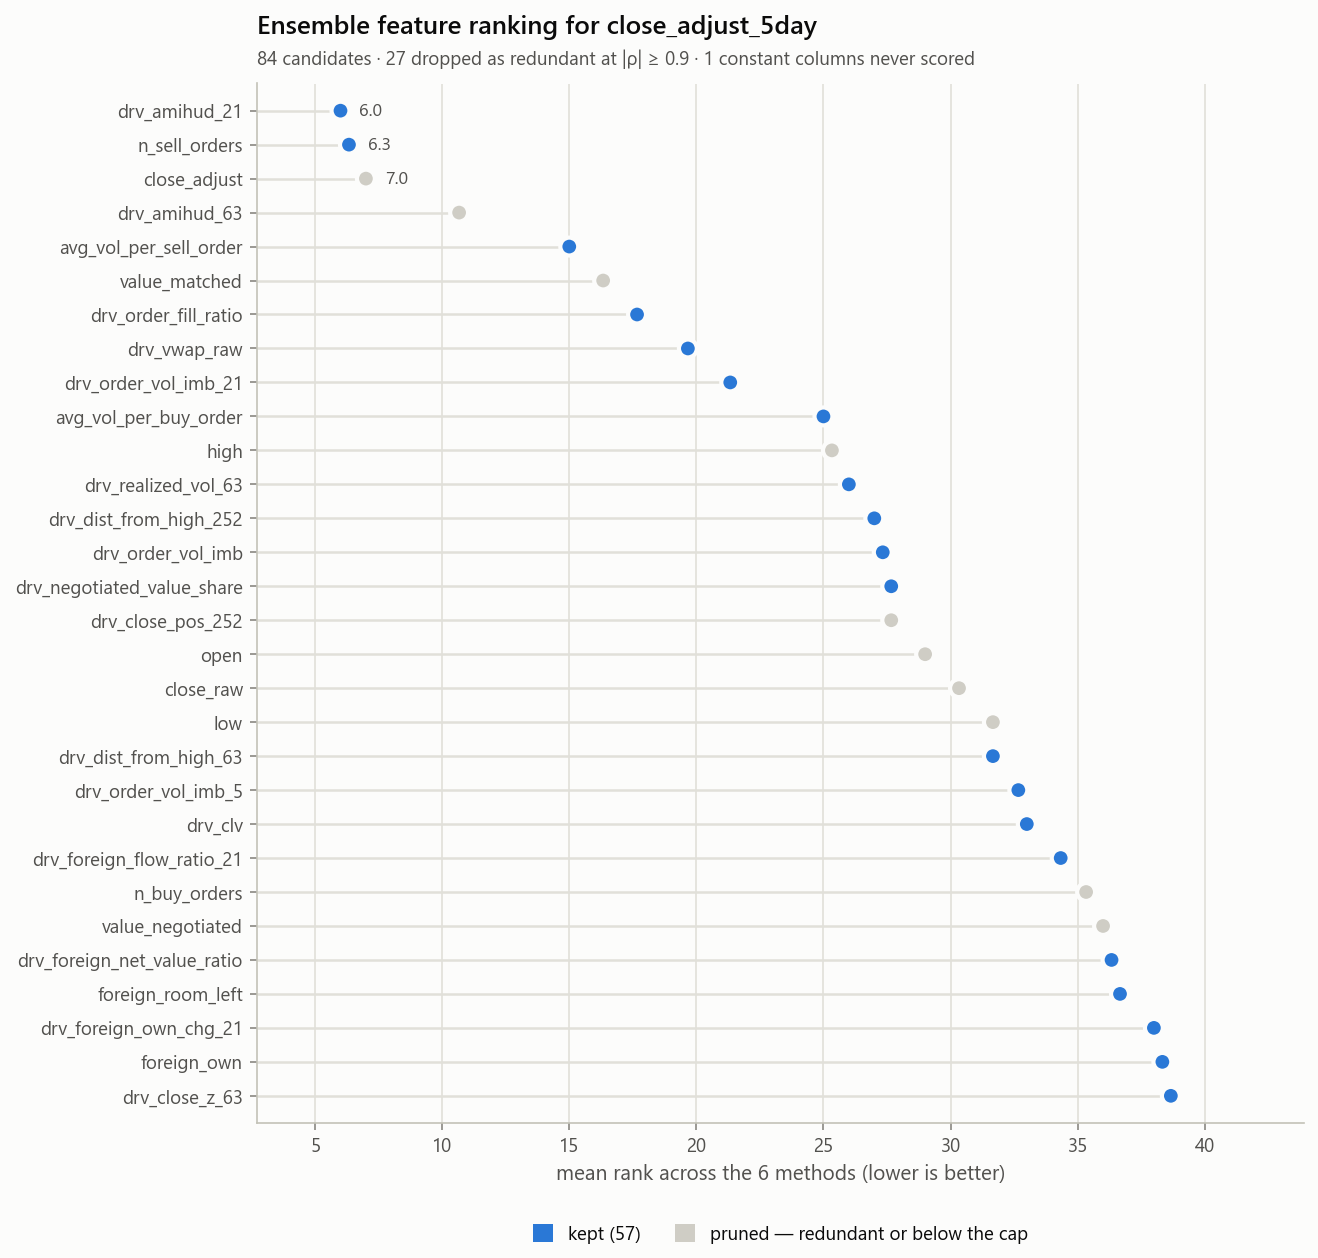

02_method_heatmap.png


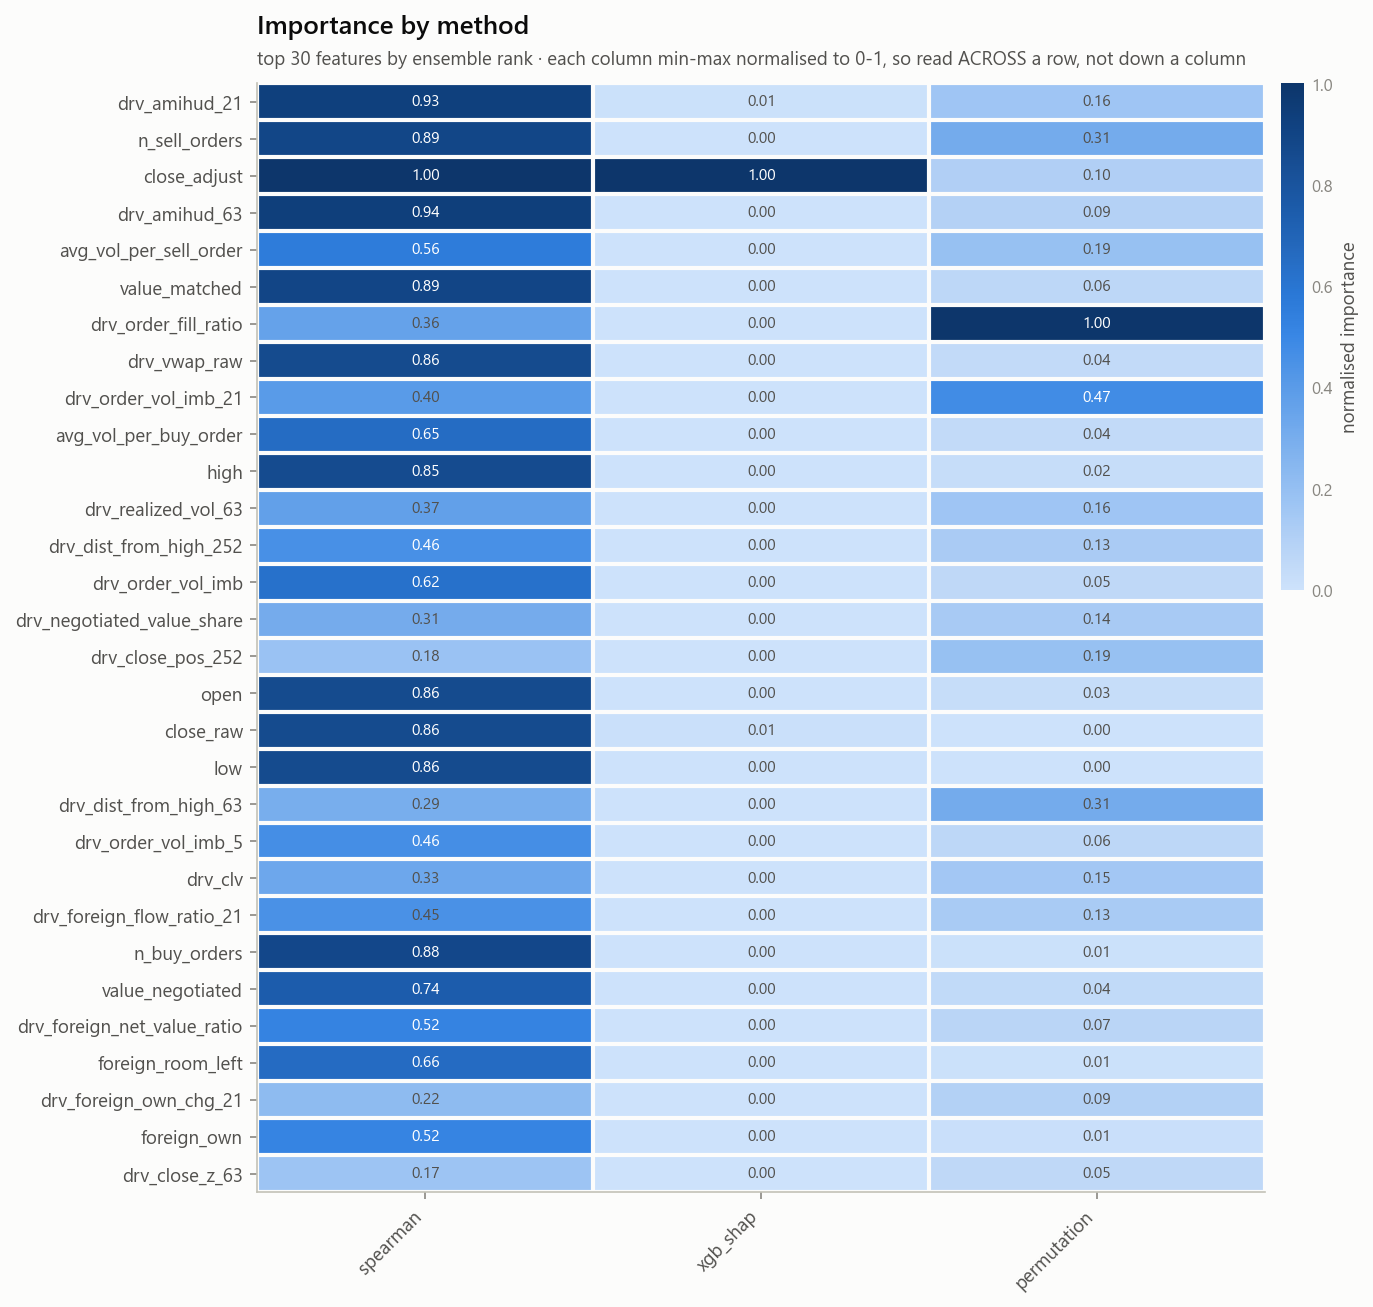

03_target_correlation.png


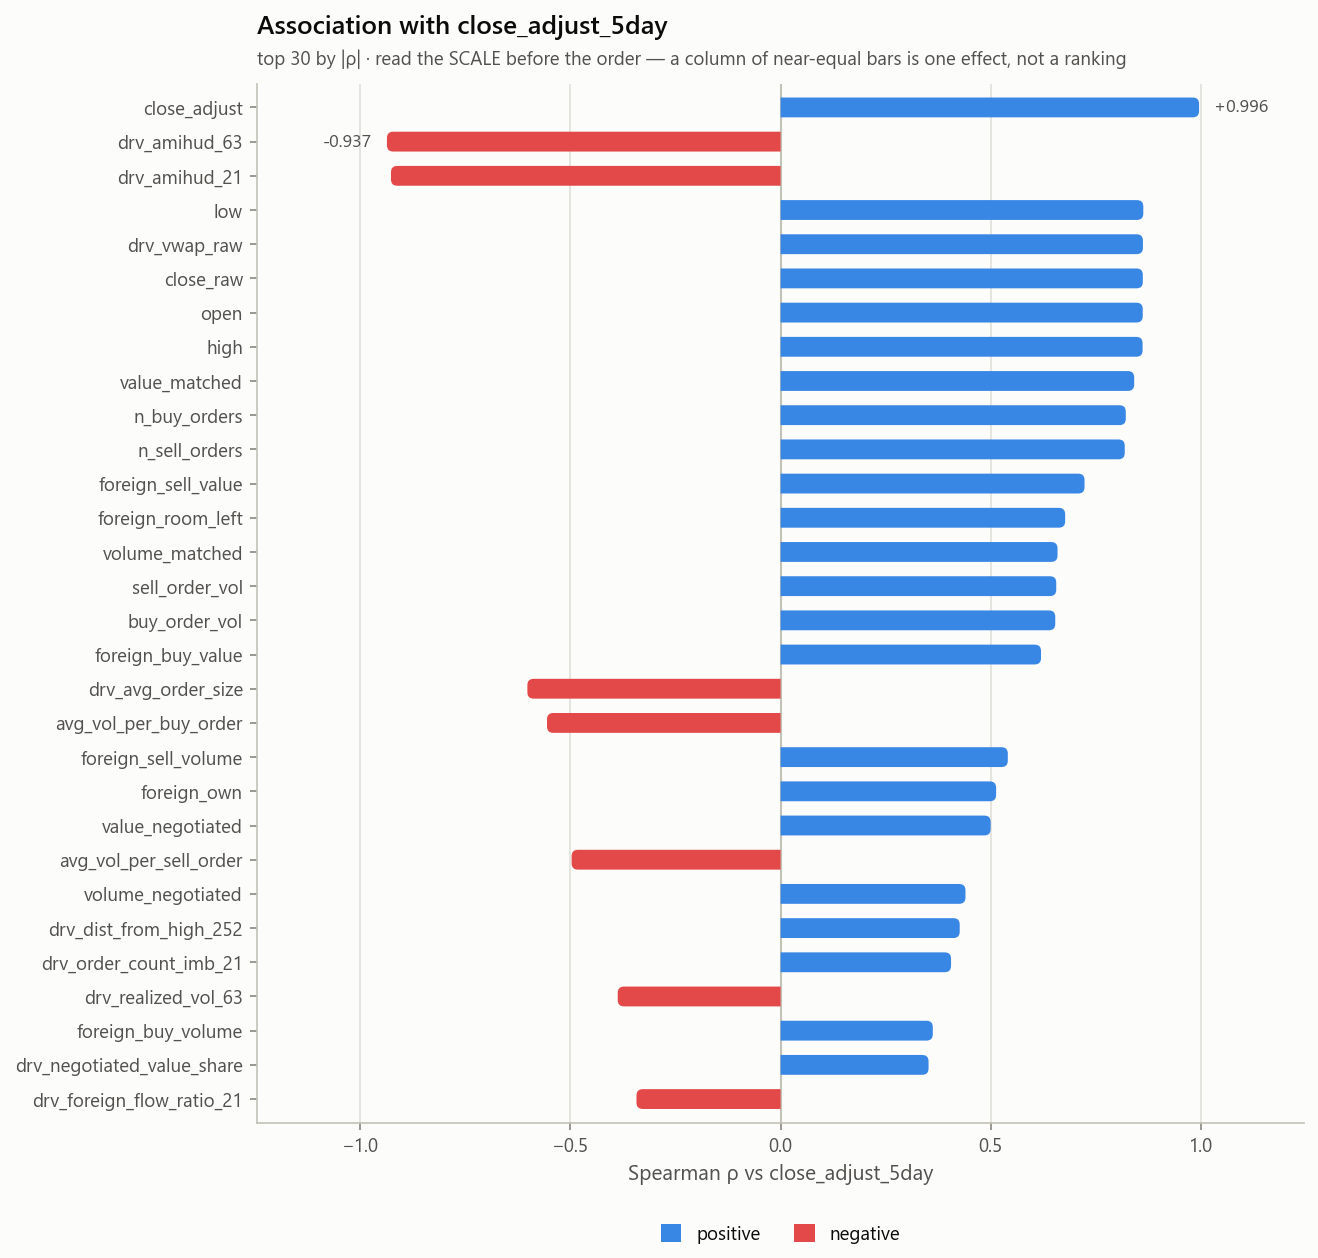

04_channel_correlation.png


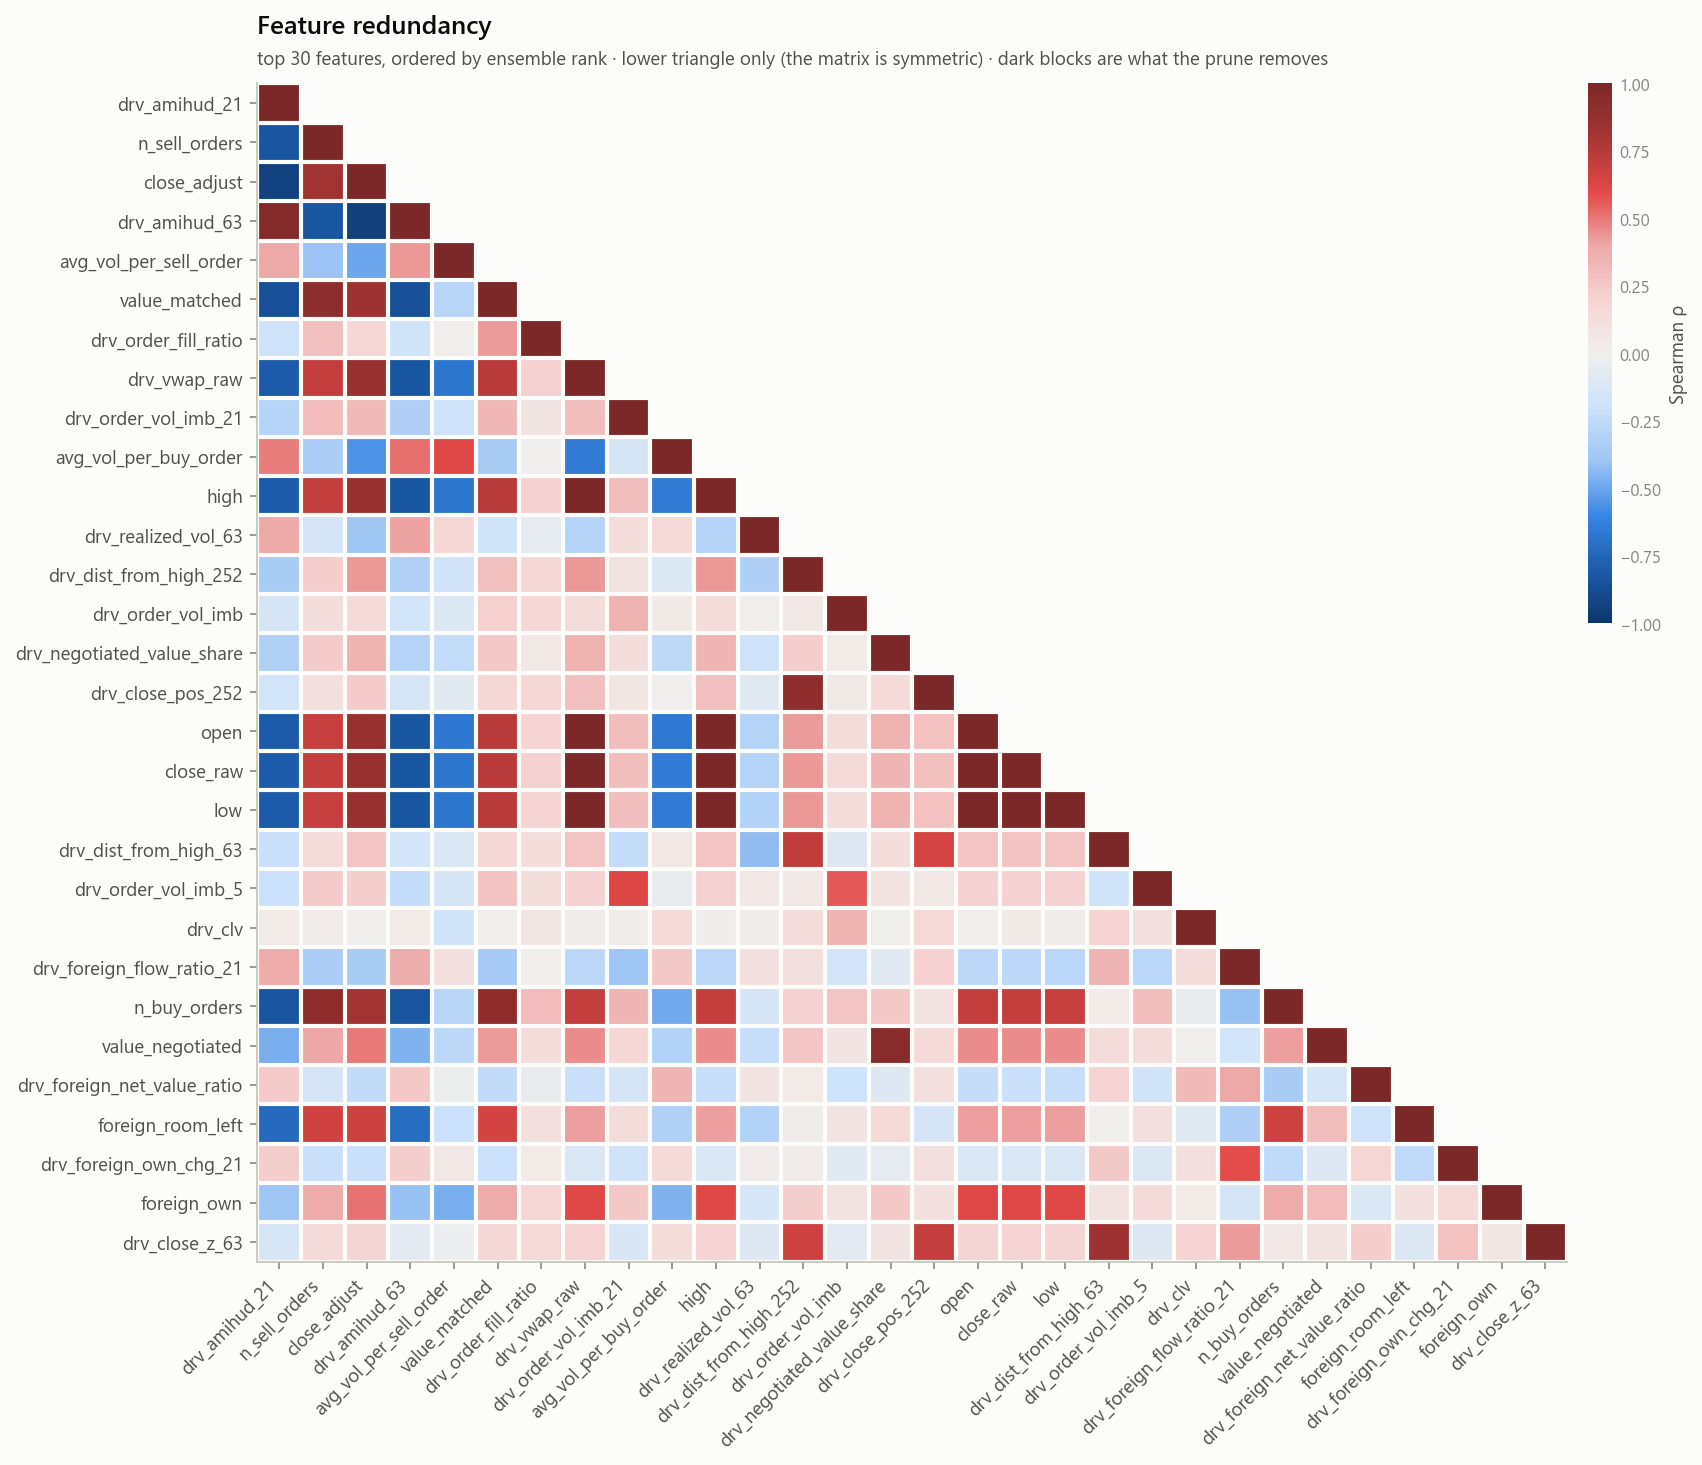

05_stat_profile.png


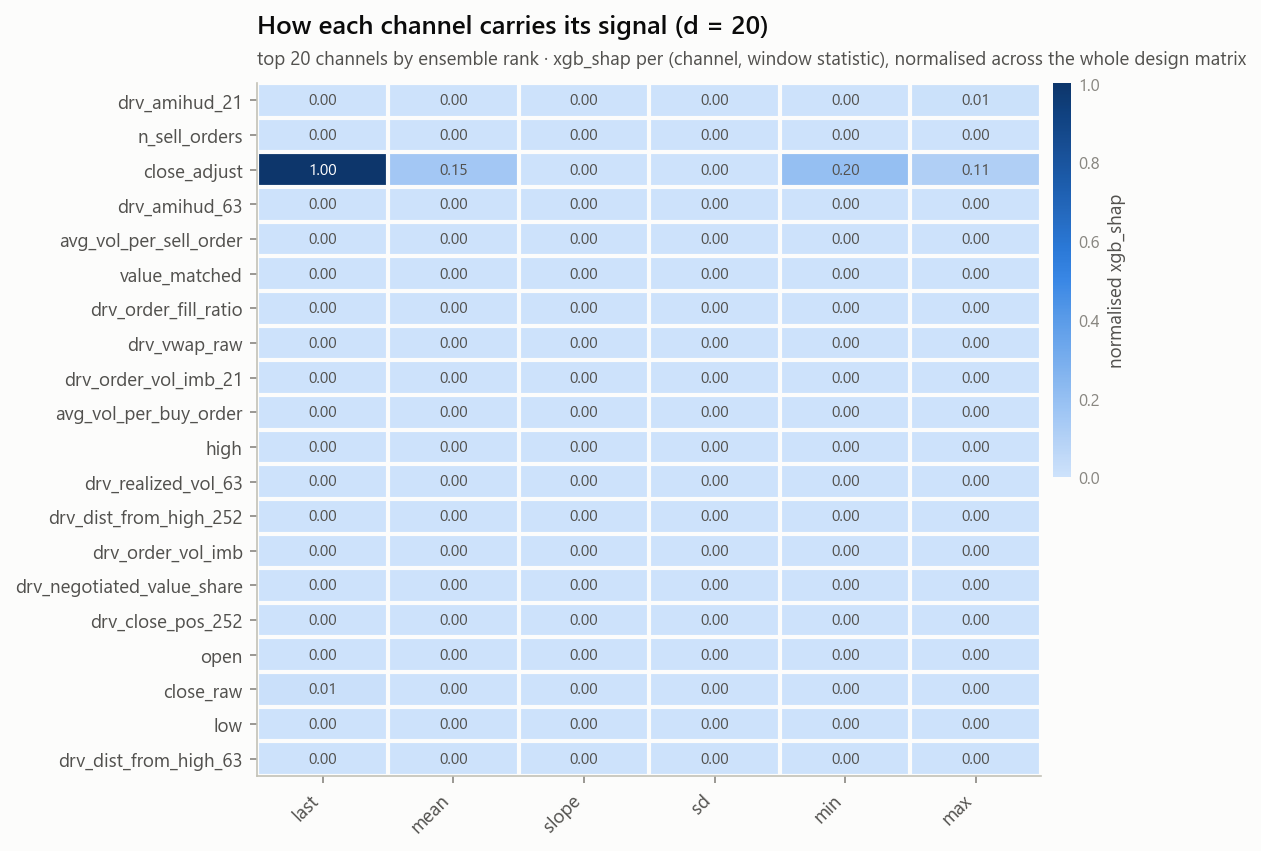

06_validation.png


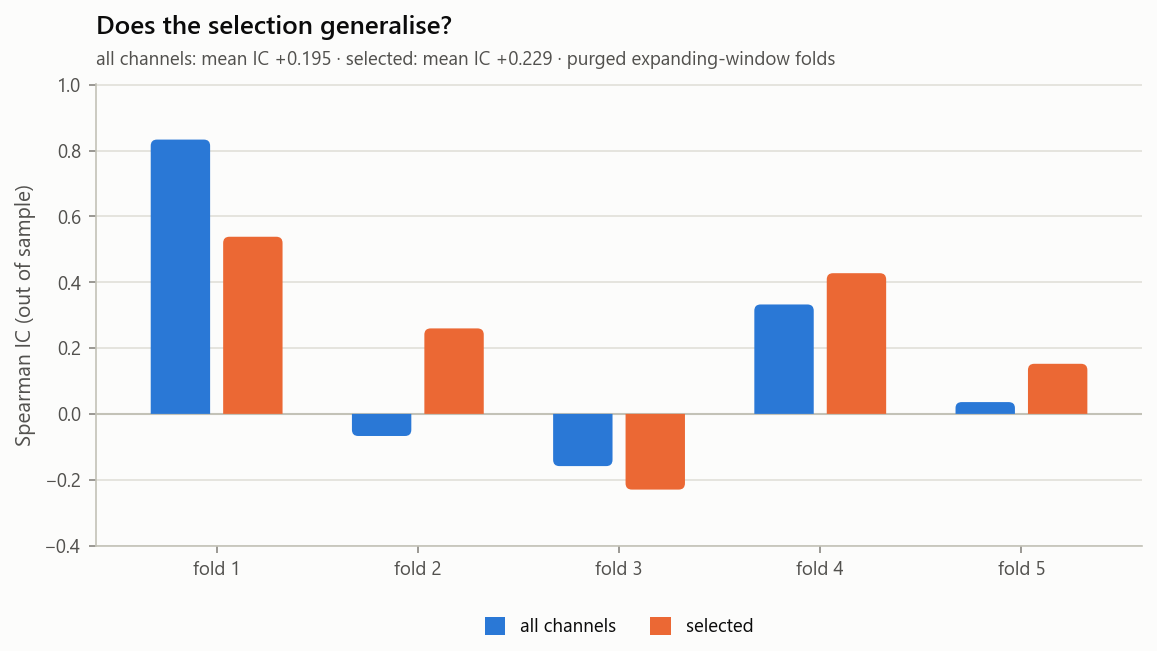

07_stability.png


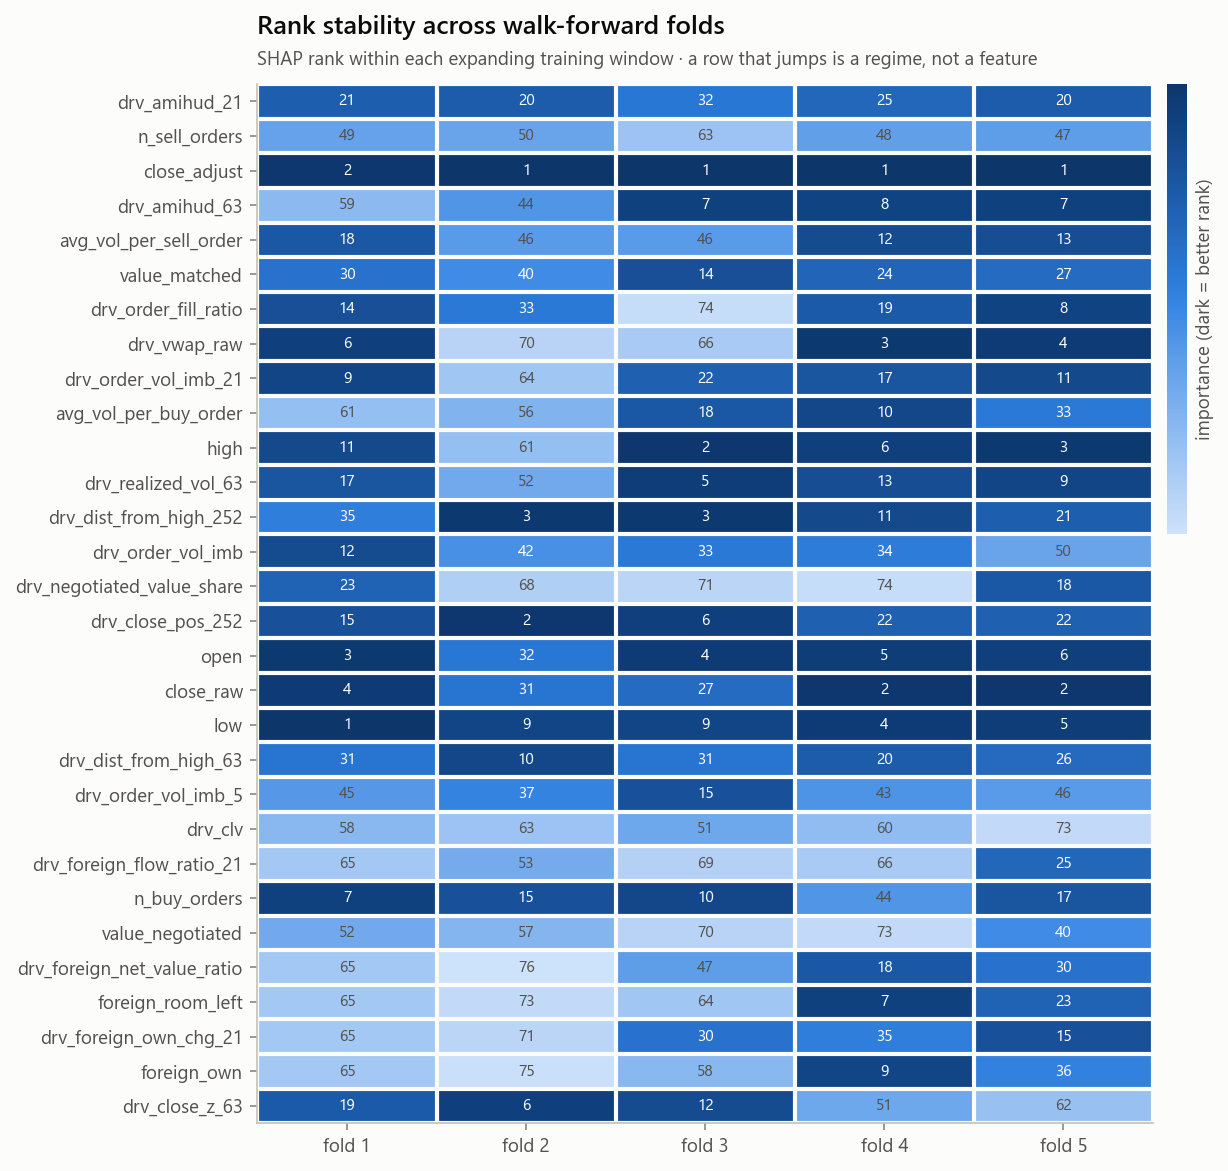

08_coverage.png


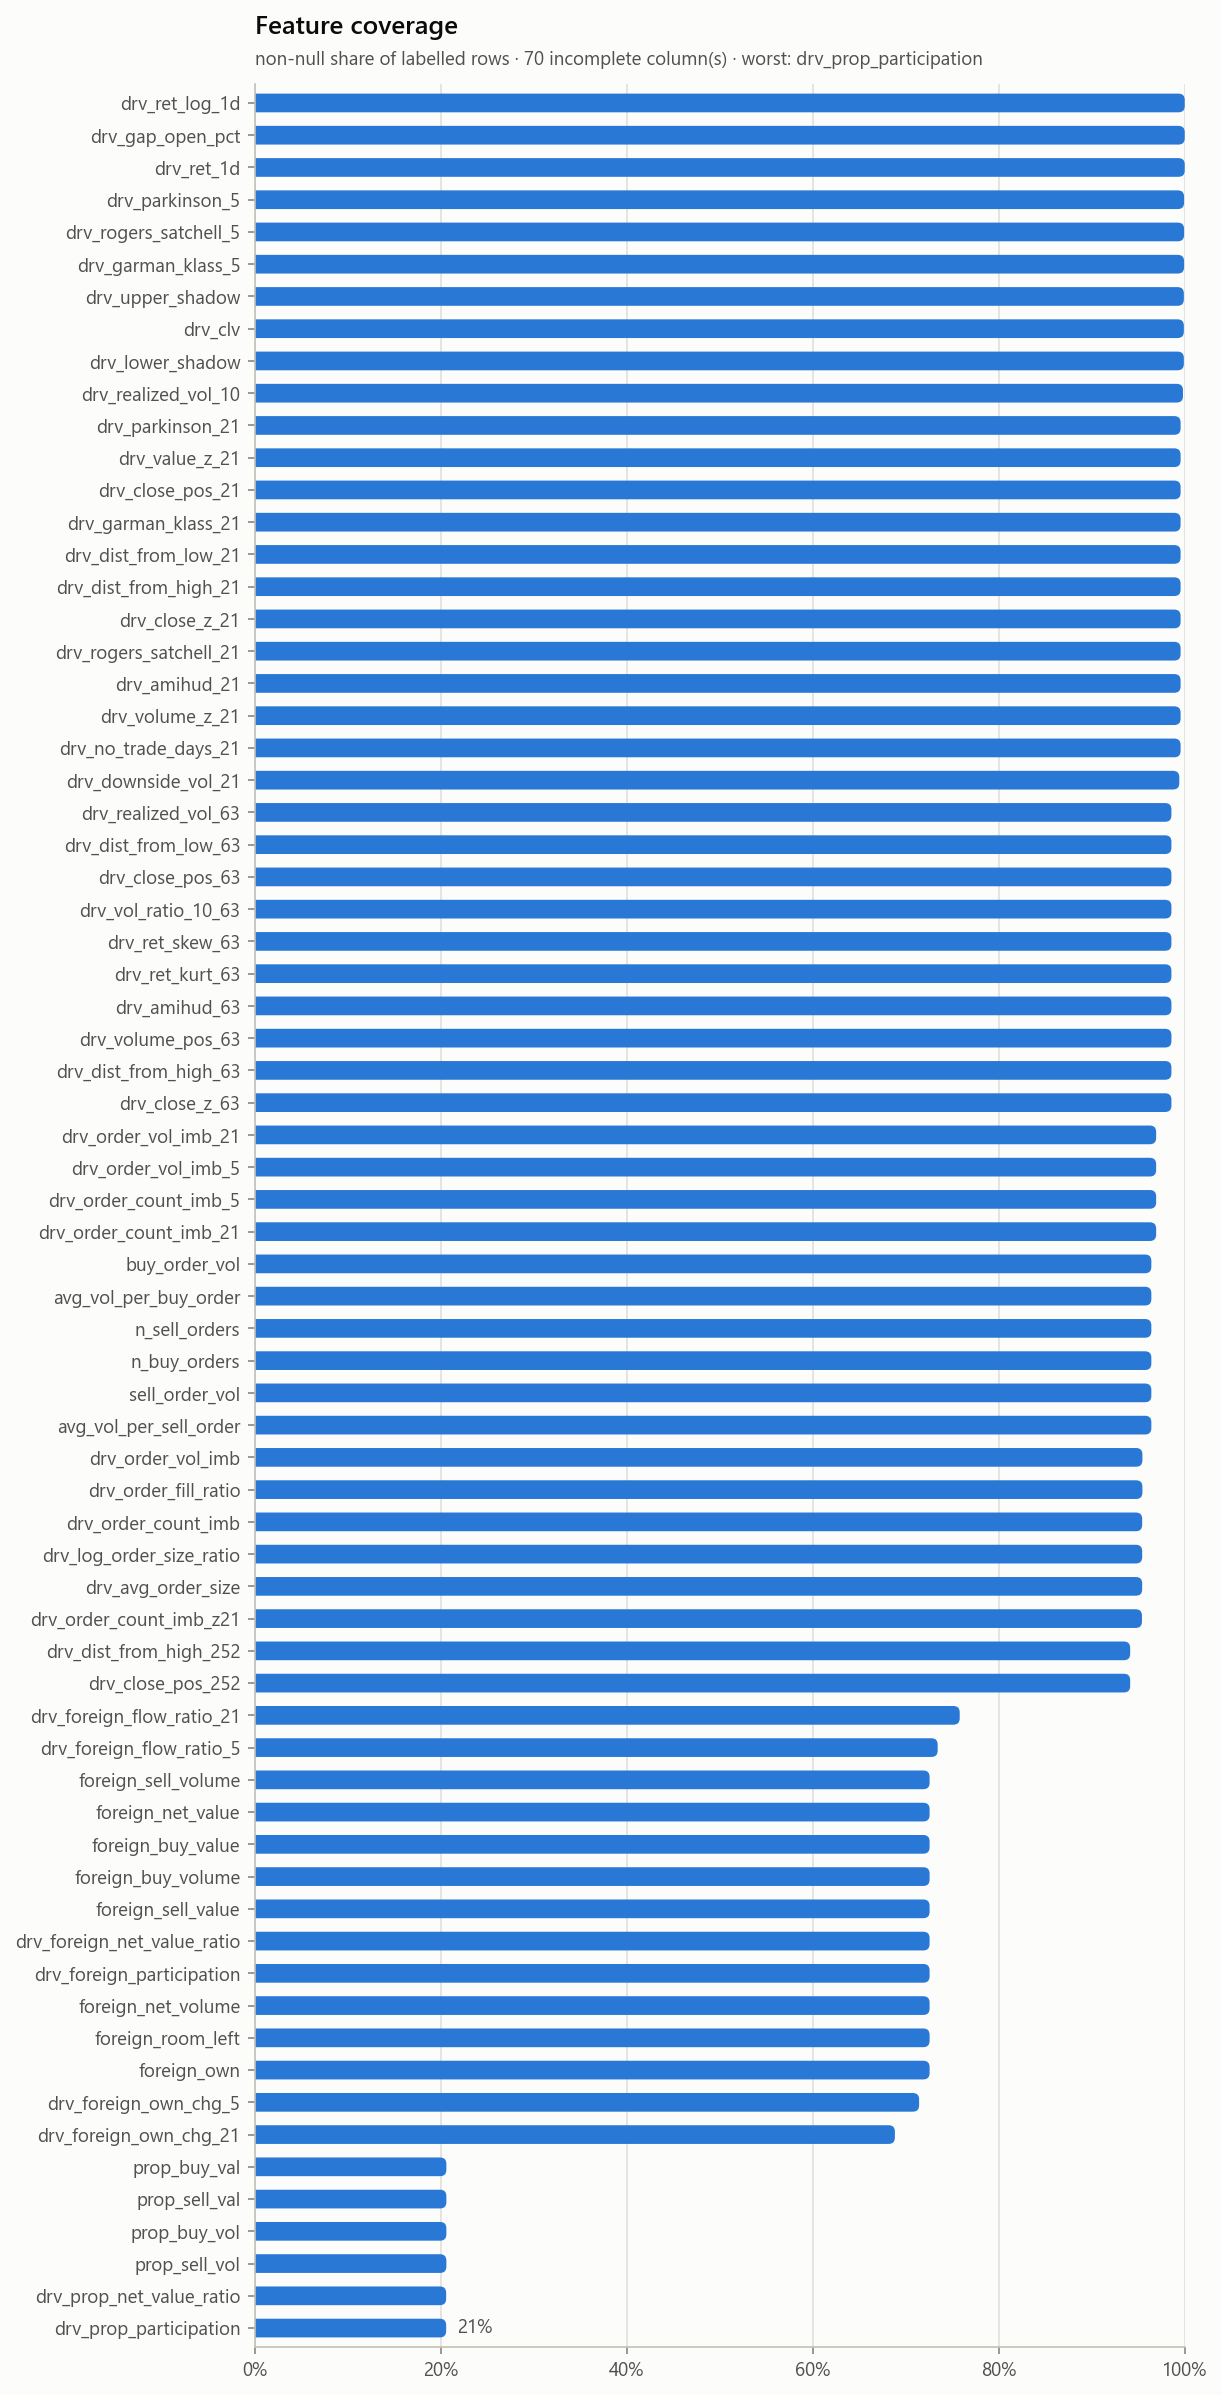

09_target_distribution.png


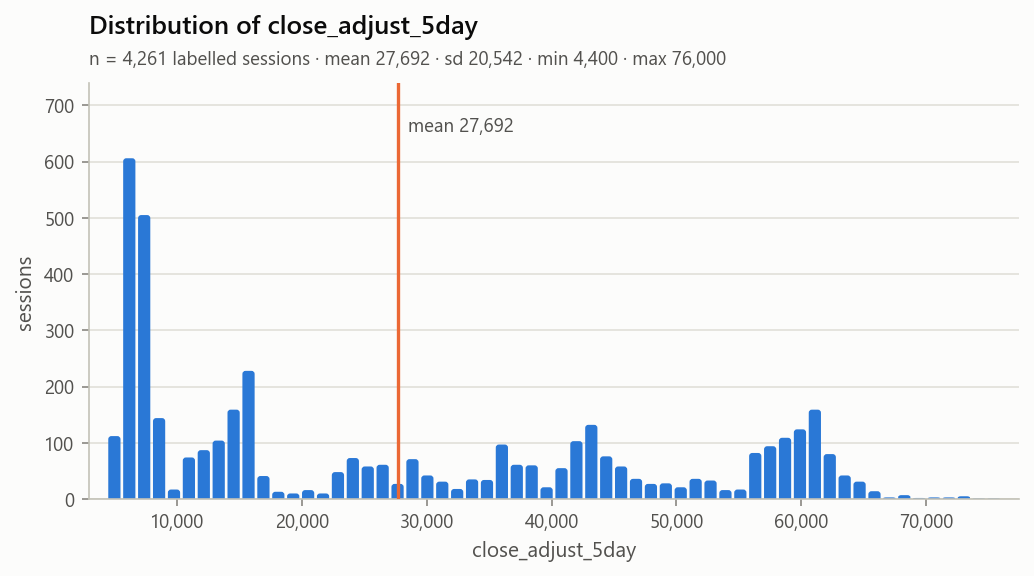

10_null.png


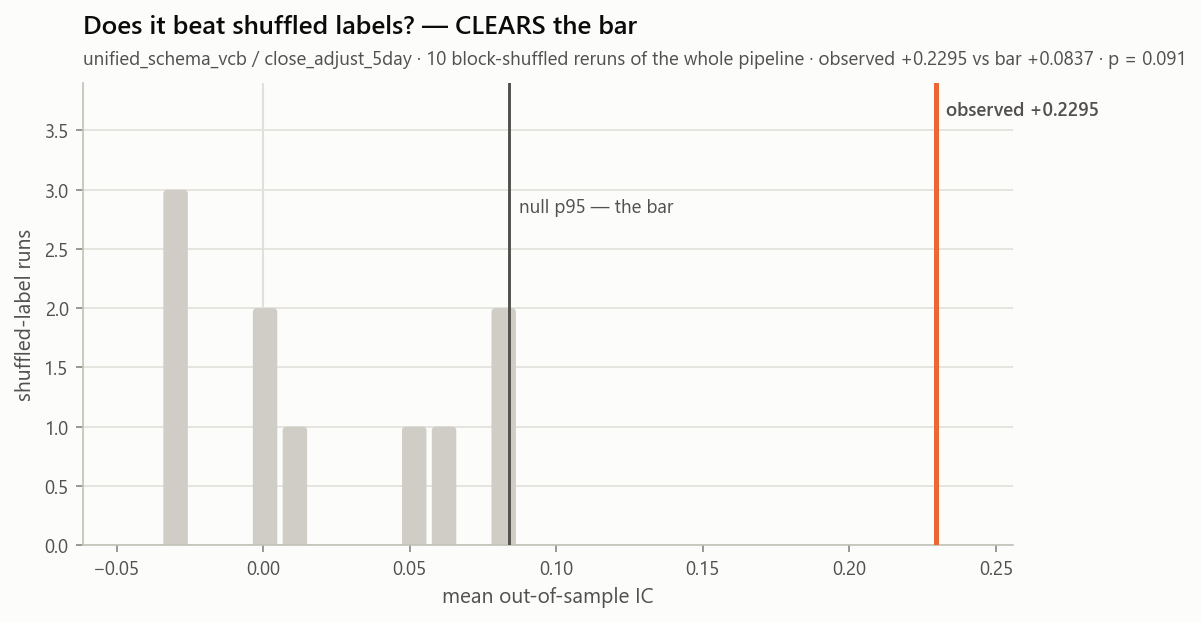

In [19]:
for figure in written.figures:
    print(os.path.basename(figure))
    display(Image(filename=figure, width=760))

### The feature-importance CSV, read back

In [20]:
pd.read_csv(written.importance_csv, index_col="channel").round(3)

,rank,ensemble,kept,dropped_for,spearman,xgb_shap,permutation,spearman_vs_target,best_stat__spearman,best_stat__xgb_shap,best_stat__permutation
channel,,,,,,,,,,,
drv_amihud_21,1,6.000,True,NaN,0.930,0.006,0.163,-0.927,min,max,sd
n_sell_orders,2,6.333,True,NaN,0.889,0.002,0.312,0.819,mean,sd,mean
close_adjust,3,7.000,False,drv_amihud_21,1.000,1.000,0.103,0.996,last,last,slope
drv_amihud_63,4,10.667,False,drv_amihud_21,0.936,0.003,0.094,-0.937,last,sd,slope
avg_vol_per_sell_order,5,15.000,True,NaN,0.559,0.002,0.188,-0.497,mean,min,min
...,...,...,...,...,...,...,...,...,...,...,...
drv_rogers_satchell_21,80,65.667,False,drv_parkinson_21,0.071,0.000,0.029,-0.092,min,slope,sd
drv_garman_klass_21,81,67.667,False,drv_parkinson_21,0.096,0.000,0.036,-0.118,min,mean,last
drv_intraday_pct,82,70.000,False,drv_body_pct,0.234,0.000,0.010,0.006,sd,max,last


## 5. Comparing runs

⚠️ **Built to make INCOMPARABILITY visible.** Two runs differing in `target`,
`normalize`, `lookback_d` or the universe are different experiments; their ICs must
not be set beside one another as if the difference were noise. `compare_reports`
puts those columns next to the IC so the difference is seen first.

In [21]:
root = report.DEFAULT_REPORT_ROOT
runs = [
    os.path.join(root, d)
    for d in sorted(os.listdir(root))
    if os.path.exists(os.path.join(root, d, "metadata.json"))
]
report.compare_reports(runs)

,run_id,schema,target,rows,tickers,lookback_d,horizon_h,normalize,feature_normalize,device,kept,ic_mean,hit_rate,null_bar,z_vs_null,clears_null,commit
0,2026-08-12_130605__vcb__economy_vietnam__close...,unified_schema_vcb,close_adjust_5day,4266,1,20,5,none,None,cuda,29,-0.034365,1.0,NaN,NaN,None,55a0072c+dirty
1,2026-08-12_205927__vcb__economy_japan__close_a...,unified_schema_vcb,close_adjust_5day,4266,1,20,5,none,None,cuda,106,-0.227133,1.0,NaN,NaN,None,ce9783e8+dirty
2,2026-08-13_001037__vcb__economy_usa__close_adj...,unified_schema_vcb,close_adjust_5day,4266,1,20,5,none,None,cuda,447,-0.112090,1.0,NaN,NaN,None,f3070061+dirty
3,2026-08-13_010024__vcb__economy_australia__clo...,unified_schema_vcb,close_adjust_5day,4266,1,20,5,none,None,cuda,101,-0.050118,1.0,NaN,NaN,None,a4dd2306+dirty
4,2026-08-13_012144__vcb__economy_european_union...,unified_schema_vcb,close_adjust_5day,4266,1,20,5,none,None,cuda,62,-0.126868,1.0,NaN,NaN,None,a4dd2306+dirty
5,2026-08-13_014705__vcb__economy_germany__close...,unified_schema_vcb,close_adjust_5day,4266,1,20,5,none,None,cuda,90,-0.200519,1.0,NaN,NaN,None,a4dd2306+dirty
6,2026-08-13_020732__vcb__economy_hong_kong_chin...,unified_schema_vcb,close_adjust_5day,4266,1,20,5,none,None,cuda,54,-0.197310,1.0,NaN,NaN,None,a4dd2306+dirty
7,2026-08-13_022416__vcb__economy_india__close_a...,unified_schema_vcb,close_adjust_5day,4266,1,20,5,none,None,cuda,50,0.039933,1.0,NaN,NaN,None,a4dd2306+dirty
8,2026-08-13_023427__vcb__economy_indonesia__clo...,unified_schema_vcb,close_adjust_5day,4266,1,20,5,none,None,cuda,51,-0.229811,1.0,NaN,NaN,None,a4dd2306+dirty
9,2026-08-13_024708__vcb__economy_mainland_china...,unified_schema_vcb,close_adjust_5day,4266,1,20,5,none,None,cuda,69,-0.154377,1.0,NaN,NaN,None,a4dd2306+dirty
